# 02 — Model v2: Multi-Class Risk Classifier
**Input:** `augmented_dataset.csv` from notebook 01  
**Output:** Trained model artifacts + evaluation report

### Pipeline
```
Text  → TF-IDF → Logistic Regression (text probabilities)
                              ↓
Structured features (policy_type, coverage_amount, ...)  
                              ↓
         Stacked SVM meta-learner (final classifier)
                              ↓
              Low / Medium / High
```


In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Ready.')

Ready.


## 1. Load Augmented Dataset

In [ ]:
try:
    from google.colab import files
    print('Running in Colab — upload augmented_dataset.csv')
    files.upload()
    df = pd.read_csv('augmented_dataset.csv')
except Exception:
    df = pd.read_csv('../augmented_dataset.csv')

print(f'Loaded: {len(df):,} rows, {df.shape[1]} cols')
print(df['risk'].value_counts())
df.head(3)

Running in Colab — upload augmented_dataset.csv


Saving augmented_dataset.csv to augmented_dataset.csv
Loaded: 15,425 rows, 9 cols
risk
Low       10435
High       2500
Medium     2490
Name: count, dtype: int64


,clause,risk,source,policy_type,coverage_amount,applicant_age,prior_claims_count,deductible_amount,state
0,Benefits may be granted depending on circumsta...,High,original_synthetic,home,363869,63,1,500,IL
1,The insurer shall compensate the insured subje...,Low,original_synthetic,auto,35313,49,0,1000,OH
2,"by way of example , and not as a limitation , ...",Low,unfair_tos,auto,69999,30,0,500,NY


## 2. Preprocessing

In [ ]:
# ── Encode labels ────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['risk'])
classes = list(le.classes_)
print('Classes:', classes, '→', le.transform(classes))

# ── Train / test split (stratified) ─────────────────────────────────────
X_text = df['clause']
X_struct = df[['policy_type','coverage_amount','applicant_age',
               'prior_claims_count','deductible_amount','state']]

(
    X_text_train, X_text_test,
    X_struct_train, X_struct_test,
    y_train, y_test
) = train_test_split(
    X_text, X_struct, y,
    test_size=0.20, stratify=y, random_state=42
)

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')

Classes: ['High', 'Low', 'Medium'] → [0 1 2]
Train: 12,340  |  Test: 3,085


In [ ]:
# ── TF-IDF on text ───────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 3), sublinear_tf=True)
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test  = tfidf.transform(X_text_test)
print('TF-IDF matrix:', X_tfidf_train.shape)

TF-IDF matrix: (12340, 20000)


In [ ]:
# ── Structured feature preprocessing ────────────────────────────────────
categorical_cols = ['policy_type', 'state']
numeric_cols     = ['coverage_amount', 'applicant_age', 'prior_claims_count', 'deductible_amount']

struct_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),  # sparse by default
    ('num', StandardScaler(),                                           numeric_cols),
])

X_struct_train_proc = struct_preprocessor.fit_transform(X_struct_train)
X_struct_test_proc  = struct_preprocessor.transform(X_struct_test)

# Convert dense numeric block back to sparse for hstacking
if hasattr(X_struct_train_proc, 'toarray'):
    pass  # already sparse
else:
    X_struct_train_proc = csr_matrix(X_struct_train_proc)
    X_struct_test_proc  = csr_matrix(X_struct_test_proc)

print('Structured features shape:', X_struct_train_proc.shape)

Structured features shape: (12340, 16)


## 3. Stage 1 — Logistic Regression on Text

LR learns the textual risk signal. Its class probabilities become features for the SVM meta-learner.

In [ ]:
lr = LogisticRegression(max_iter=3000, solver='lbfgs', C=1.0, multi_class='multinomial')
lr.fit(X_tfidf_train, y_train)

lr_proba_train = lr.predict_proba(X_tfidf_train)  # shape (n_train, n_classes)
lr_proba_test  = lr.predict_proba(X_tfidf_test)

print('LR text-only accuracy:', round(lr.score(X_tfidf_test, y_test), 4))
print('Per-class report:')
print(classification_report(y_test, lr.predict(X_tfidf_test), target_names=classes))

LR text-only accuracy: 0.9673
Per-class report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       500
         Low       0.96      1.00      0.98      2087
      Medium       0.99      0.81      0.89       498

    accuracy                           0.97      3085
   macro avg       0.98      0.93      0.95      3085
weighted avg       0.97      0.97      0.97      3085



## 4. Stage 2 — SVM Meta-Learner (Text Proba + Structured Features)

The SVM receives: `[TF-IDF features | LR class probabilities | structured features]`  
This lets it learn from both the raw text signal and the policy context simultaneously.

In [ ]:
# ── Build combined feature matrix ────────────────────────────────────────
X_combined_train = hstack([
    X_tfidf_train,
    csr_matrix(lr_proba_train),
    X_struct_train_proc,
])
X_combined_test = hstack([
    X_tfidf_test,
    csr_matrix(lr_proba_test),
    X_struct_test_proc,
])
print('Combined feature matrix:', X_combined_train.shape)

Combined feature matrix: (12340, 20019)


In [ ]:
# ── Train SVM ────────────────────────────────────────────────────────────
# Wrap in CalibratedClassifierCV so we get calibrated probabilities
svm_base = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_calibrated = CalibratedClassifierCV(svm_base, cv=3, method='sigmoid')
svm_calibrated.fit(X_combined_train, y_train)

y_pred  = svm_calibrated.predict(X_combined_test)
y_proba = svm_calibrated.predict_proba(X_combined_test)

print('SVM (calibrated) accuracy:', round((y_pred == y_test).mean(), 4))

SVM (calibrated) accuracy: 0.9724


## 5. Evaluation

In [ ]:
print('='*55)
print('CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test, y_pred, target_names=classes))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       500
         Low       0.97      0.99      0.98      2087
      Medium       0.95      0.88      0.91       498

    accuracy                           0.97      3085
   macro avg       0.97      0.95      0.96      3085
weighted avg       0.97      0.97      0.97      3085



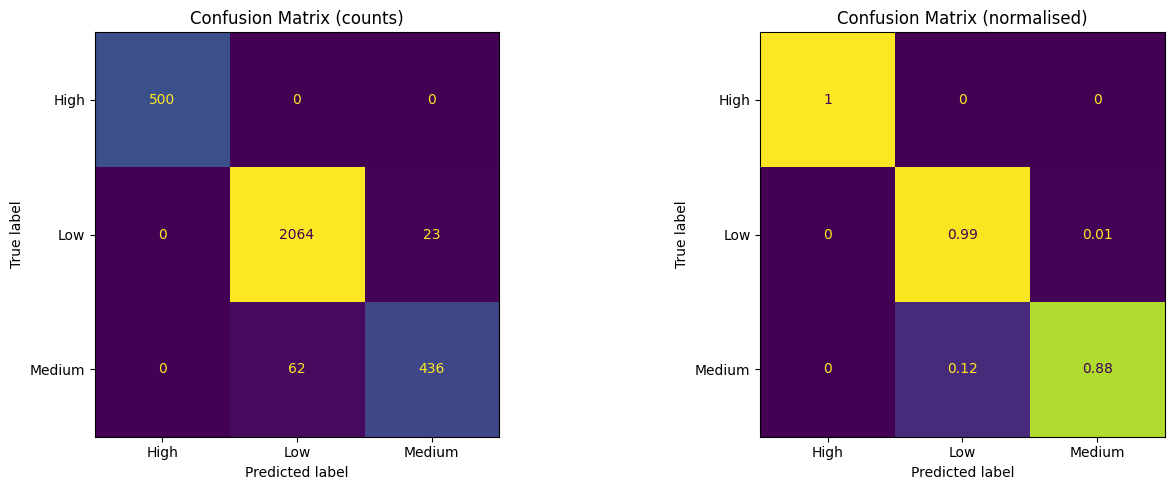

In [ ]:
# ── Confusion matrix ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (counts)')

# Normalised
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=classes).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix (normalised)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── ROC-AUC (one-vs-rest) ────────────────────────────────────────────────
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=range(len(classes)))
auc_scores = {}
for i, cls in enumerate(classes):
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    auc_scores[cls] = round(auc, 4)

print('ROC-AUC (one-vs-rest):')
for cls, score in auc_scores.items():
    print(f'  {cls:8s}: {score}')

ROC-AUC (one-vs-rest):
  High    : 1.0
  Low     : 0.995
  Medium  : 0.9905


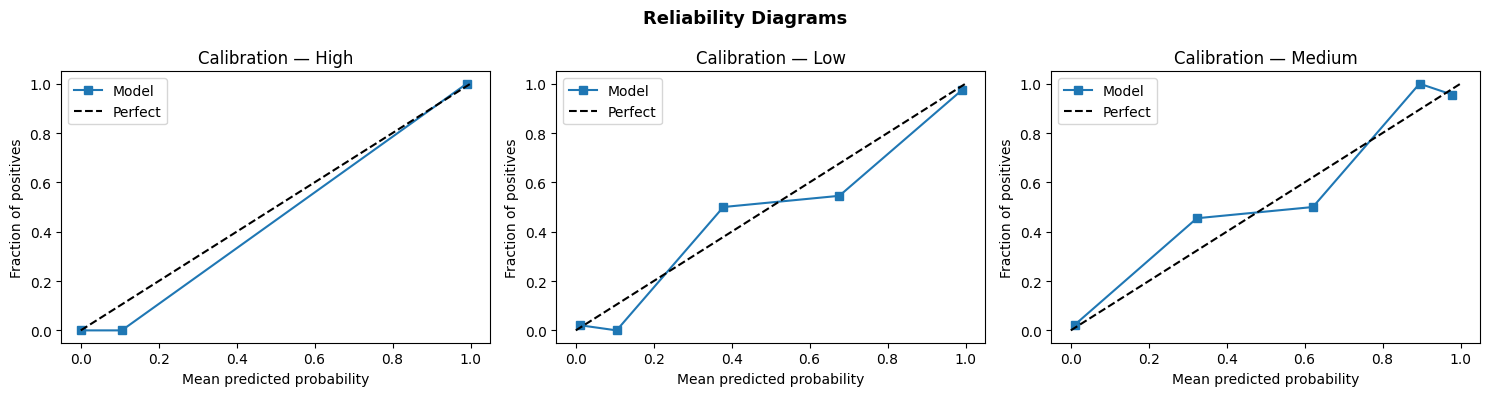

In [ ]:
# ── Calibration curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 4))
if len(classes) == 1:
    axes = [axes]

for i, cls in enumerate(classes):
    frac_pos, mean_pred = calibration_curve(
        y_test_bin[:, i], y_proba[:, i], n_bins=10
    )
    axes[i].plot(mean_pred, frac_pos, 's-', label='Model')
    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect')
    axes[i].set_title(f'Calibration — {cls}')
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Fraction of positives')
    axes[i].legend()

plt.suptitle('Reliability Diagrams', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

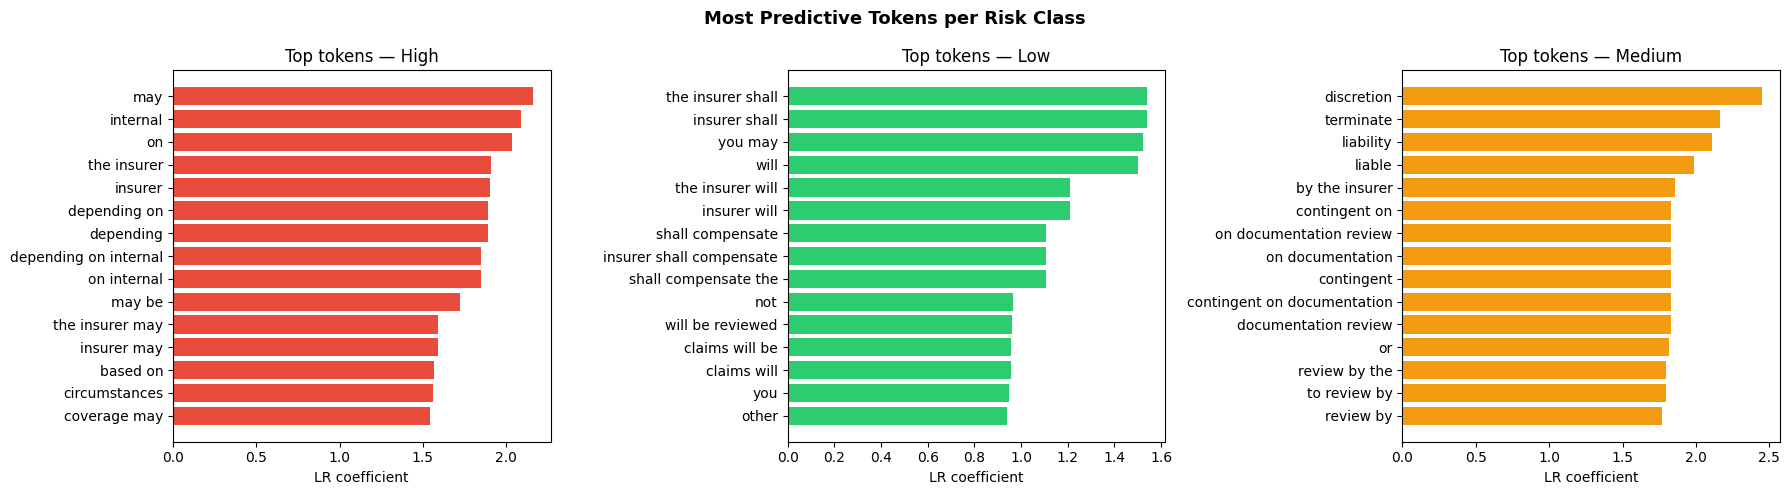

In [ ]:
# ── Top TF-IDF tokens per class ──────────────────────────────────────────
feature_names = tfidf.get_feature_names_out()
TOP_N = 15

fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5))
if len(classes) == 1:
    axes = [axes]

colors_map = {'High': '#e74c3c', 'Low': '#2ecc71', 'Medium': '#f39c12'}

for i, cls in enumerate(classes):
    coef = lr.coef_[i]
    top_idx = np.argsort(coef)[-TOP_N:][::-1]
    top_tokens = [feature_names[j] for j in top_idx]
    top_coefs  = [coef[j] for j in top_idx]
    color = colors_map.get(cls, 'steelblue')
    axes[i].barh(top_tokens[::-1], top_coefs[::-1], color=color)
    axes[i].set_title(f'Top tokens — {cls}')
    axes[i].set_xlabel('LR coefficient')

plt.suptitle('Most Predictive Tokens per Risk Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Inference latency benchmark ──────────────────────────────────────────
import time

sample_clauses = df['clause'].sample(200, random_state=1).tolist()
sample_struct  = df[['policy_type','coverage_amount','applicant_age',
                      'prior_claims_count','deductible_amount','state']].sample(200, random_state=1)

start = time.perf_counter()
for i, clause in enumerate(sample_clauses):
    vec   = tfidf.transform([clause])
    prob  = lr.predict_proba(vec)
    s_vec = struct_preprocessor.transform(sample_struct.iloc[[i]])
    if not hasattr(s_vec, 'toarray'):
        s_vec = csr_matrix(s_vec)
    combined = hstack([vec, csr_matrix(prob), s_vec])
    _ = svm_calibrated.predict(combined)
elapsed = time.perf_counter() - start

print(f'200 predictions in {elapsed:.3f}s')
print(f'Avg per clause   : {elapsed/200*1000:.1f} ms')

200 predictions in 4.283s
Avg per clause   : 21.4 ms


## 6. Save Model Artifacts

In [ ]:
os.makedirs('artifacts', exist_ok=True)

joblib.dump(tfidf,                'artifacts/tfidf_vectorizer.pkl')
joblib.dump(lr,                   'artifacts/lr_model.pkl')
joblib.dump(svm_calibrated,       'artifacts/svm_model.pkl')
joblib.dump(le,                   'artifacts/label_encoder.pkl')
joblib.dump(struct_preprocessor,  'artifacts/struct_preprocessor.pkl')

print('Saved:')
for f in os.listdir('artifacts'):
    size = os.path.getsize(f'artifacts/{f}') / 1024
    print(f'  artifacts/{f}  ({size:.1f} KB)')

Saved:
  artifacts/svm_model.pkl  (3102.2 KB)
  artifacts/label_encoder.pkl  (0.5 KB)
  artifacts/lr_model.pkl  (469.6 KB)
  artifacts/tfidf_vectorizer.pkl  (838.9 KB)
  artifacts/struct_preprocessor.pkl  (3.0 KB)


## 7. Inference Helper (used by the API)

In [ ]:
!pip install python-dotenv -q
from dotenv import load_dotenv
load_dotenv("/content/.env")

import re
import os

# ── Risk flag patterns ───────────────────────────────────────────────────
RISK_FLAG_PATTERNS = {
    'ambiguous_trigger':   r'(may|might|could).{0,40}(apply|cover|compensate)',
    'insurer_discretion':  r'insurer.{0,25}(sole|absolute|reasonable)?\s*discretion',
    'blanket_exclusion':   r'(does not cover|no coverage|excluded from coverage|not covered)',
    'conditional_payout':  r'(subject to|depending on|provided that|contingent on)',
    'vague_conditions':    r'(certain (situations|circumstances)|relevant circumstances|internal evaluation)',
    'unilateral_change':   r'(reserves? the right|may (modify|amend|change|terminate))',
}

FLAG_DESCRIPTIONS = {
    'ambiguous_trigger':  "uses 'may/might' instead of a definitive commitment",
    'insurer_discretion': 'gives the insurer sole discretion to decide outcomes',
    'blanket_exclusion':  'contains a broad exclusion of coverage',
    'conditional_payout': 'makes payout conditional on insurer-controlled factors',
    'vague_conditions':   'uses vague language with no clear trigger conditions',
    'unilateral_change':  'allows the insurer to change terms without consent',
}

def get_flags(clause):
    return [flag for flag, pat in RISK_FLAG_PATTERNS.items()
            if re.search(pat, clause, re.IGNORECASE)]

# ── Gemini 2.5 Flash rewriter ─────────────────────────────────────────────
import google.generativeai as genai

GEMINI_API_KEY = ""  # paste your key here or set env var
if not GEMINI_API_KEY:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")

gemini_model = None
if GEMINI_API_KEY:
    genai.configure(api_key=GEMINI_API_KEY)
    gemini_model = genai.GenerativeModel("gemini-2.5-flash")
    print("Gemini 2.5 Flash ready.")
else:
    print("GEMINI_API_KEY not set — rewriting will be skipped.")
    print("Get a free key: https://aistudio.google.com/app/apikey")

def rewrite_clause(clause, risk_label, flags):
    if gemini_model is None:
        return None
    reasons = "; ".join(FLAG_DESCRIPTIONS.get(f, f) for f in flags) if flags else "vague language"
    prompt = f"""You are an expert insurance policy attorney rewriting clauses for the policyholder.

This clause is {risk_label} risk because it {reasons}.

Rewrite it to:
- Use definitive language (will/shall not may/might)
- Specify exact objective conditions for coverage
- Remove insurer-sole-discretion language
- Be fair and unambiguous

Original: {clause}

Return only the rewritten clause."""
    try:
        resp = gemini_model.generate_content(prompt)
        return resp.text.strip().strip('"')
    except Exception as e:
        print(f"Rewrite error: {e}")
        return None

# ── Full inference pipeline ───────────────────────────────────────────────
def predict_risk(clause, policy_meta):
    vec  = tfidf.transform([clause])
    prob = lr.predict_proba(vec)

    meta_df = pd.DataFrame([policy_meta])
    s_vec = struct_preprocessor.transform(meta_df)
    if not hasattr(s_vec, 'toarray'):
        s_vec = csr_matrix(s_vec)

    combined    = hstack([vec, csr_matrix(prob), s_vec])
    label_idx   = svm_calibrated.predict(combined)[0]
    label_proba = svm_calibrated.predict_proba(combined)[0]
    risk_label  = le.inverse_transform([label_idx])[0]
    flags       = get_flags(clause)

    rewritten = rewrite_clause(clause, risk_label, flags) if risk_label in ('High', 'Medium') else None

    return {
        'risk_label':       risk_label,
        'risk_score':       round(float(label_proba[label_idx]), 4),
        'confidence':       round(float(label_proba.max()), 4),
        'lr_probabilities': {cls: round(float(p), 4) for cls, p in zip(le.classes_, prob[0])},
        'flags':            flags,
        'rewritten_clause': rewritten,
    }

# ── Test ──────────────────────────────────────────────────────────────────
test_clause = "Coverage may apply in certain situations subject to evaluation by the insurer."
test_meta = {
    'policy_type': 'commercial', 'coverage_amount': 1500000,
    'applicant_age': 45, 'prior_claims_count': 3,
    'deductible_amount': 5000, 'state': 'TX',
}
result = predict_risk(test_clause, test_meta)
print("
Test prediction:")
for k, v in result.items():
    print(f"  {k}: {v}")


Test prediction:
  risk_label: High
  risk_score: 0.9937
  confidence: 0.9937
  lr_probabilities: {'High': 0.9755, 'Low': 0.0125, 'Medium': 0.0119}
  flags: ['ambiguous_trigger', 'conditional_payout', 'vague_conditions']


In [ ]:
# Download artifacts in Colab
try:
    from google.colab import files
    import shutil
    shutil.make_archive('artifacts', 'zip', 'artifacts')
    files.download('artifacts.zip')
    print('artifacts.zip downloaded — extract into model/artifacts/')
except Exception:
    print('Not in Colab — artifacts saved locally in ./artifacts/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

artifacts.zip downloaded — extract into model/artifacts/
